# Optimización de Hiperparámetros con Optuna
## LightGBM + feval `hotel_recall_minus_fpratio` — Fraude en Hospedaje (MCC 7011)

**Objetivo**: Encontrar la configuración de hiperparámetros de LightGBM que maximice la detección de fraude hotelero minimizando los falsos positivos, usando como función objetivo la métrica M2 definida en el notebook 04.

**Estrategia**:
1. Búsqueda bayesiana con Optuna (TPE Sampler) sobre el espacio de hiperparámetros de LightGBM
2. Early stopping en cada trial usando M2 como feval en validación (mes 5)
3. Reentreno del modelo final con los mejores parámetros sobre todo el train (meses 1–5)
4. Evaluación final en test junio con comparación vs baseline

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from pathlib import Path
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)
import warnings, json
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", None)

# ── Configuración global ──────────────────────────────────────────────────
RANDOM_STATE    = 42
N_TRIALS        = 120      # trials Optuna
EARLY_STOPPING  = 40       # rondas sin mejora para parar
NUM_BOOST_MAX   = 800      # máximo de árboles por trial
ALPHA_M2        = 0.5      # peso del FP ratio en M2 (early stopping)
MIN_RECALL      = 0.65     # SLA de recall en hospedaje (restricción de la métrica)
THRESHOLDS      = np.round(np.linspace(0.05, 0.90, 18), 3)  # rejilla fina de umbrales

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Optuna    : {optuna.__version__}")
print(f"LightGBM  : {lgb.__version__}")
print(f"Resultados: {RESULTS_DIR}")

Optuna    : 4.8.0
LightGBM  : 4.6.0
Resultados: /Users/davisroldanordonez/Universidad/security-science/Proyecto2-SecurityDS-PlusTI/results


## 2. Carga de datos y preparación de matrices

In [2]:
train_df = pd.read_csv(DATA_PROC / "train_features.csv")
test_df  = pd.read_csv(DATA_PROC / "test_features_june.csv")

for col in ["is_fraud","is_international","is_hotel","hotel_international","hotel_high_distance"]:
    for df in [train_df, test_df]:
        if col in df.columns:
            df[col] = df[col].astype(bool)

TARGET = "is_fraud"
manual_drop = {
    TARGET,
    "transaction_id","pan_masked","pan_hash","DE2_PAN",
    "DE35_track2_data_masked","DE37_retrieval_reference_number",
    "DE38_authorization_code","DE41_terminal_id","DE42_card_acceptor_id",
    "DE43_card_acceptor_name_location","DE102_account_id_1","DE103_account_id_2",
    "client_home_city","bank_code","bank_name","bank_country","bank_tier",
    "approved","DE39_response_code","response_description",
    "DE44_additional_response_data","transaction_date","transaction_datetime",
}

def prep_features(df_ref, others):
    """One-hot encoding consistente: dummies sobre df_ref; el resto se alinea a esas columnas.
    Devuelve [X_ref, *X_others] con el MISMO espacio de columnas."""
    all_cols  = [c for c in df_ref.columns if c not in manual_drop]
    cat_cols  = df_ref[all_cols].select_dtypes(include=["object","category","string"]).columns.tolist()
    low_card  = [c for c in cat_cols if df_ref[c].nunique() <= 50]
    high_card = [c for c in cat_cols if df_ref[c].nunique() >  50]
    feat_cols = [c for c in all_cols if c not in high_card]

    X_ref = pd.get_dummies(df_ref[feat_cols], columns=low_card, drop_first=True, dtype=float)
    out   = [X_ref.reset_index(drop=True)]
    for o in others:
        Xo = pd.get_dummies(o[feat_cols], columns=low_card, drop_first=True, dtype=float)
        out.append(Xo.reindex(columns=X_ref.columns, fill_value=0).reset_index(drop=True))
    if high_card:
        print(f"  Descartadas por alta cardinalidad: {high_card}")
    return out, list(X_ref.columns)

# Matriz consistente sobre TODO el train (meses 1-5) + test alineado al mismo espacio.
(X_train_all, X_test), FEAT_COLS = prep_features(train_df, [test_df])
y_train_all = train_df[TARGET].astype(int).reset_index(drop=True)
y_test      = test_df[TARGET].astype(int).reset_index(drop=True)

month_train     = train_df["transaction_month"].values
hotel_train     = train_df["is_hotel"].values.astype(bool)
hotel_mask_test = test_df["is_hotel"].values.astype(bool)
y_test_np       = y_test.values

# Slices retro-compatibles: train interno (meses 1-4) y validación (mes 5)
_tr_idx = np.where(month_train < 5)[0]
_va_idx = np.where(month_train == 5)[0]
X_train, y_train = X_train_all.iloc[_tr_idx].reset_index(drop=True), y_train_all.iloc[_tr_idx].reset_index(drop=True)
X_val,   y_val   = X_train_all.iloc[_va_idx].reset_index(drop=True), y_train_all.iloc[_va_idx].reset_index(drop=True)
hotel_mask_val   = hotel_train[_va_idx]
y_val_np         = y_val.values

# Reentreno final usa meses 1-5 completos
X_train_full, y_train_full = X_train_all, y_train_all

print(f"Train total (1-5): {X_train_all.shape[0]:,} | Test junio: {X_test.shape[0]:,}")
print(f"Features          : {X_train_all.shape[1]}")
print(f"Hotel val (mes 5) : {hotel_mask_val.sum()} txns  | fraudes: {y_val_np[hotel_mask_val].sum()}")
print(f"Hotel test (jun)  : {hotel_mask_test.sum()} txns  | fraudes: {y_test_np[hotel_mask_test].sum()}")

  Descartadas por alta cardinalidad: ['client_id']
Train total (1-5): 83,817 | Test junio: 16,186
Features          : 112
Hotel val (mes 5) : 1511 txns  | fraudes: 73
Hotel test (jun)  : 1457 txns  | fraudes: 73


### 2.1 Por qué NO usamos accuracy — el clasificador trivial

Como advirtieron los asesores: por el fuerte desbalance (~5% de fraude), un modelo que predice **siempre "no-fraude"** alcanza una accuracy altísima sin detectar un solo fraude. Lo verificamos abajo para justificar que la métrica del proyecto es **FP ratio con recall ≥ 65%** (no accuracy): el clasificador trivial **reprueba** esa métrica.

In [3]:
# Clasificador trivial "todo = no-fraude" (predicción constante 0)
print("Clasificador trivial — predice SIEMPRE 'no-fraude':\n")
for _name, _y in [("Global junio", y_test_np),
                  ("Hotel junio ", y_test_np[hotel_mask_test])]:
    acc = (1 - _y.mean()) * 100          # accuracy = proporción de negativos
    n_fraude = int(_y.sum())
    print(f"  {_name} | accuracy = {acc:5.2f}%  | fraudes reales no detectados = {n_fraude} "
          f"| recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido")

print("\n→ Accuracy ~95% pero recall = 0%: inútil para fraude.")
print("→ El clasificador trivial NO cumple el SLA recall ≥ 65%, así que reprueba la")
print("  métrica del proyecto (FP ratio con recall ≥ 65%). Por eso optimizamos esa métrica.")

Clasificador trivial — predice SIEMPRE 'no-fraude':

  Global junio | accuracy = 95.45%  | fraudes reales no detectados = 736 | recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido
  Hotel junio  | accuracy = 94.99%  | fraudes reales no detectados = 73 | recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido

→ Accuracy ~95% pero recall = 0%: inútil para fraude.
→ El clasificador trivial NO cumple el SLA recall ≥ 65%, así que reprueba la
  métrica del proyecto (FP ratio con recall ≥ 65%). Por eso optimizamos esa métrica.


## 3. feval M2 — `hotel_recall_minus_fpratio`

Métrica de optimización principal: `recall_hotel − α · FP_ratio_hotel`.  
Búsqueda dinámica de umbral en cada evaluación para evitar colapso con el desbalance de clases.

In [4]:
def _cm_hotel(y_h, p_h, t):
    y_pred = (p_h >= t).astype(int)
    tp = int(np.sum((y_h == 1) & (y_pred == 1)))
    fp = int(np.sum((y_h == 0) & (y_pred == 1)))
    fn = int(np.sum((y_h == 1) & (y_pred == 0)))
    return tp, fp, fn


def make_feval_m2(mask, y_true_full, alpha=ALPHA_M2):
    """Closure: feval hotel_recall_minus_fpratio (se usa SOLO para early stopping)."""
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p   = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
            s   = rec - alpha * fpr
            if s > best:
                best = s
        return "hotel_recall_minus_fpratio", best, True
    return feval


def hotel_fpratio_score(p_h, y_h, min_recall=MIN_RECALL):
    """Score alineado a la métrica del proyecto: minimizar FP ratio en hotel
    sujeto a recall ≥ min_recall. Devuelve un valor a MAXIMIZAR:
      - si algún umbral logra recall ≥ min_recall → (1 - FP_ratio) ∈ [0, 1]
      - si ninguno lo logra → (mejor_recall - min_recall) < 0  (guía hacia el SLA)
    Así la optimización persigue exactamente lo que se evalúa, no un proxy."""
    best_ok   = -np.inf      # mejor (1 - fpr) con recall cumplido
    best_rec  = 0.0          # mejor recall alcanzado (por si nadie cumple SLA)
    for t in THRESHOLDS:
        tp, fp, fn = _cm_hotel(y_h, p_h, t)
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
        best_rec = max(best_rec, rec)
        if rec >= min_recall:
            best_ok = max(best_ok, 1.0 - fpr)
    return best_ok if best_ok > -np.inf else (best_rec - min_recall)


feval_m2_val = make_feval_m2(hotel_mask_val, y_val_np)

# Verificación rápida con predicciones aleatorias
_dummy = np.random.rand(len(y_val_np))
_name, _val, _higher = feval_m2_val(_dummy, None)
print(f"feval_m2_val (dummy): {_name} = {_val:.4f}  higher_better={_higher}")
print(f"hotel_fpratio_score (dummy): {hotel_fpratio_score(_dummy[hotel_mask_val], y_val_np[hotel_mask_val]):.4f}")
print("✅ Métricas listas.")

feval_m2_val (dummy): hotel_recall_minus_fpratio = 0.5115  higher_better=True
hotel_fpratio_score (dummy): 0.0573
✅ Métricas listas.


## 4. Función objetivo de Optuna (objetivo alineado + espacio regularizado)

La versión anterior sobreajustaba (FP ratio 32% en junio, peor que el nb04). Diagnóstico: el FP ratio en hotel lo gobierna el **ranking** del modelo, no el peso de clase (el barrido de umbral absorbe la calibración); los modelos **complejos** (num_leaves alto) y `scale_pos_weight` extremo **empeoran** el ranking del segmento hotel.

Tres correcciones:

1. **Objetivo alineado a la métrica del proyecto**: se maximiza `1 − FP_ratio_hotel` sujeto a `recall_hotel ≥ 0.65` (con penalización si no se alcanza el SLA), en lugar del proxy `recall − 0.5·FP_ratio` que sobre-pesaba el recall.
2. **Espacio de búsqueda regularizado**: `num_leaves ≤ 31`, `scale_pos_weight ≤ 6`, regularización L1/L2 y árboles poco profundos → mejor ranking en hotel y mejor generalización a junio.
3. **Validación en el mes 5** (adyacente a junio = mejor proxy temporal), con la configuración ganadora del nb04 anclada como primer trial (`enqueue_trial`).

In [5]:
# ── Validación = mes 5 (adyacente a junio → el mejor proxy disponible) ─────
# Train interno = meses 1-4. El diagnóstico mostró que el FP ratio en hotel lo
# gobierna el RANKING del modelo, no el peso de clase (el barrido de umbral
# absorbe la calibración). Modelos simples (num_leaves pequeño) y scale_pos_weight
# bajo rankean mejor el segmento hotel → menor FP ratio. Por eso el espacio se
# restringe agresivamente a esa región (evita el num_leaves=147/spw=13 que
# disparaba el FP ratio a ~32%).
tr_idx14 = np.where(month_train < 5)[0]
val_idx5 = np.where(month_train == 5)[0]
h_val5   = hotel_train[val_idx5]
y_val5   = y_train_all.values[val_idx5]
print(f"Train interno (1-4): {len(tr_idx14):,} | Validación (mes 5): {len(val_idx5):,} "
      f"| fraudes hotel val: {int(y_val5[h_val5].sum())}")


def objective(trial: optuna.Trial) -> float:
    params = {
        # arquitectura — DELIBERADAMENTE pequeña (mejor ranking en hotel)
        "num_leaves":        trial.suggest_int("num_leaves", 7, 31),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
        "max_bin":           trial.suggest_int("max_bin", 63, 255),
        # learning
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
        "subsample":         trial.suggest_float("subsample", 0.7, 1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # regularización
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 2.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 2.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 0.3),
        # desbalance — rango BAJO (spw alto degrada el ranking en hotel)
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 6.0),
        # fijos
        "objective":     "binary",
        "force_col_wise": True,
        "verbose":       -1,
        "random_state":  RANDOM_STATE,
        "n_jobs":        4,
    }
    mb = params["max_bin"]

    X_tr, y_tr = X_train_all.iloc[tr_idx14], y_train_all.iloc[tr_idx14]
    X_va, y_va = X_train_all.iloc[val_idx5], y_train_all.iloc[val_idx5]

    ds_tr = lgb.Dataset(X_tr, label=y_tr, params={"max_bin": mb}, free_raw_data=False)
    ds_va = lgb.Dataset(X_va, label=y_va, reference=ds_tr,
                        params={"max_bin": mb}, free_raw_data=False)

    booster = lgb.train(
        params, ds_tr,
        num_boost_round = NUM_BOOST_MAX,
        valid_sets      = [ds_va],
        valid_names     = ["val"],
        feval           = make_feval_m2(h_val5, y_val5),   # solo para early stopping
        callbacks       = [lgb.early_stopping(EARLY_STOPPING, verbose=False),
                           lgb.log_evaluation(period=0)],
    )
    trial.set_user_attr("best_iteration", booster.best_iteration)
    p = np.clip(booster.predict(X_va, num_iteration=booster.best_iteration), 0, 1)
    # Objetivo = 1 - FP_ratio_hotel en validación, sujeto a recall ≥ MIN_RECALL
    return hotel_fpratio_score(p[h_val5], y_val5[h_val5])


print("\nFunción objetivo definida (validación mes 5, objetivo = 1 − FP_ratio_hotel | recall ≥ %.2f)." % MIN_RECALL)
print(f"Espacio REGULARIZADO (num_leaves≤31, scale_pos_weight≤6)  |  {N_TRIALS} trials.")

Train interno (1-4): 66,644 | Validación (mes 5): 17,173 | fraudes hotel val: 73

Función objetivo definida (validación mes 5, objetivo = 1 − FP_ratio_hotel | recall ≥ 0.65).
Espacio REGULARIZADO (num_leaves≤31, scale_pos_weight≤6)  |  120 trials.


## 5. Búsqueda bayesiana con Optuna (TPE Sampler)

In [6]:
study = optuna.create_study(
    direction  = "maximize",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=20),
    pruner     = optuna.pruners.NopPruner(),
    study_name = "lgb_hotel_fraud_fpratio",
)

# Anclar la configuración ganadora del nb04 (modelo simple, scale_pos_weight bajo)
# como primer trial → la búsqueda nunca arranca por debajo de ese referente y,
# de no encontrar algo mejor en validación, al menos lo iguala.
study.enqueue_trial({
    "num_leaves": 15, "max_depth": 7, "min_child_samples": 40, "max_bin": 63,
    "learning_rate": 0.06, "subsample": 0.85, "colsample_bytree": 0.85,
    "reg_alpha": 0.05, "reg_lambda": 0.10, "min_split_gain": 0.0,
    "scale_pos_weight": 1.0,
})

print(f"Ejecutando {N_TRIALS} trials…")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_trial
_fpr_cv = (1 - best.value) if best.value >= 0 else None
print(f"\n{'='*55}")
print(f"Mejor trial   : #{best.number}")
print(f"Mejor score   : {best.value:.4f}  (= 1 − FP_ratio_hotel con recall ≥ {MIN_RECALL} en val mes 5)")
print(f"FP ratio val  : {_fpr_cv*100:.1f}%" if _fpr_cv is not None else f"(SLA recall no alcanzado: {best.value:.4f})")
print(f"Mejor iter    : {best.user_attrs.get('best_iteration', 'N/A')} árboles")
print(f"\nHiperparámetros óptimos:")
for k, v in best.params.items():
    print(f"  {k:<22}: {v}")

Ejecutando 120 trials…


  0%|          | 0/120 [00:00<?, ?it/s]


Mejor trial   : #108
Mejor score   : 0.9057  (= 1 − FP_ratio_hotel con recall ≥ 0.65 en val mes 5)
FP ratio val  : 9.4%
Mejor iter    : 48 árboles

Hiperparámetros óptimos:
  num_leaves            : 23
  max_depth             : 7
  min_child_samples     : 48
  max_bin               : 106
  learning_rate         : 0.03779473199403418
  subsample             : 0.9747685223958898
  colsample_bytree      : 0.7139840268845102
  reg_alpha             : 0.0021279562938068494
  reg_lambda            : 0.024381020171729467
  min_split_gain        : 0.2638199163683407
  scale_pos_weight      : 1.2181392804507292


## 6. Análisis de la búsqueda

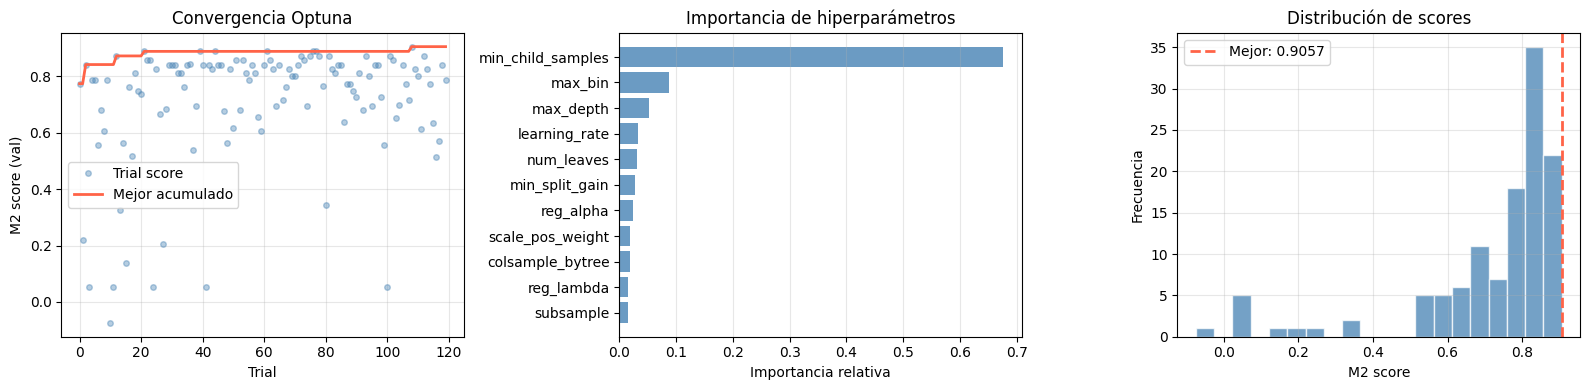

Trials guardados: results/optuna_trials.csv

Top 5 trials:
 number    value
    108 0.905660
     44 0.888889
     76 0.888889
     21 0.888889
     39 0.888889


In [7]:
trials_df = study.trials_dataframe(attrs=("number","value","params","user_attrs"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Convergencia ──
ax = axes[0]
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
ax.plot(vals, "o", alpha=0.4, markersize=4, color="steelblue", label="Trial score")
ax.plot(best_so_far, "-", color="tomato", linewidth=2, label="Mejor acumulado")
ax.set_xlabel("Trial"); ax.set_ylabel("M2 score (val)")
ax.set_title("Convergencia Optuna"); ax.legend(); ax.grid(alpha=0.3)

# ── Importancia de hiperparámetros ──
ax2 = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    keys   = list(importance.keys())
    values = list(importance.values())
    ax2.barh(keys[::-1], values[::-1], color="steelblue", alpha=0.8)
    ax2.set_xlabel("Importancia relativa"); ax2.set_title("Importancia de hiperparámetros")
    ax2.grid(alpha=0.3, axis="x")
except Exception as e:
    ax2.text(0.5, 0.5, str(e), ha="center", va="center", transform=ax2.transAxes)

# ── Distribución de scores ──
ax3 = axes[2]
ax3.hist(vals, bins=20, color="steelblue", alpha=0.75, edgecolor="white")
ax3.axvline(best.value, color="tomato", linewidth=2, linestyle="--",
            label=f"Mejor: {best.value:.4f}")
ax3.set_xlabel("M2 score"); ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de scores"); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optuna_study_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# Guardar resultados del estudio
trials_df.to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)
print(f"Trials guardados: results/optuna_trials.csv")
print(f"\nTop 5 trials:")
print(trials_df.sort_values("value", ascending=False).head(5)[
    ["number", "value"]
].to_string(index=False))


## 7. Modelo final — reentreno con mejores hiperparámetros (meses 1–5)

In [8]:
best_params = {**best.params,
               "subsample_freq": 1,
               "objective": "binary", "force_col_wise": True,
               "verbose": -1, "random_state": RANDOM_STATE, "n_jobs": 4}
best_n_iter = max(int(best.user_attrs.get("best_iteration", 200)), 30)

# Reentreno sobre meses 1-5 completos (train_full) con num_boost_round fijo.
# El Dataset se construye con el max_bin óptimo (mismo fix que en la búsqueda).
lgb_full_ds = lgb.Dataset(X_train_full, label=y_train_full,
                          params={"max_bin": best_params["max_bin"]},
                          free_raw_data=False)

final_model = lgb.train(
    best_params,
    lgb_full_ds,
    num_boost_round = best_n_iter,
    callbacks       = [lgb.log_evaluation(period=0)],
)

print(f"Modelo final entrenado con {best_n_iter} árboles sobre {len(y_train_full):,} filas (meses 1-5).")
print(f"Parámetros usados:")
for k, v in best_params.items():
    if k not in {"objective","force_col_wise","verbose","random_state","n_jobs"}:
        print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

Modelo final entrenado con 48 árboles sobre 83,817 filas (meses 1-5).
Parámetros usados:
  num_leaves            : 23
  max_depth             : 7
  min_child_samples     : 48
  max_bin               : 106
  learning_rate         : 0.0378
  subsample             : 0.9748
  colsample_bytree      : 0.7140
  reg_alpha             : 0.0021
  reg_lambda            : 0.0244
  min_split_gain        : 0.2638
  scale_pos_weight      : 1.2181
  subsample_freq        : 1


## 8. Evaluación en Test Junio

In [9]:
proba_test  = np.clip(final_model.predict(X_test), 0, 1)
proba_hotel = proba_test[hotel_mask_test]
y_hotel     = y_test_np[hotel_mask_test]

# ── Sweep de umbrales en TEST (hotel) ──────────────────────────────────────
threshold_rows = []
for t in THRESHOLDS:
    tp, fp, fn = _cm_hotel(y_hotel, proba_hotel, t)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fpr  = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    threshold_rows.append({"t": round(float(t),3), "tp": tp, "fp": fp, "fn": fn,
                            "recall": rec, "precision": prec, "fp_ratio": fpr})

thr_df = pd.DataFrame(threshold_rows)
valid  = thr_df[thr_df["recall"] >= MIN_RECALL]
best_t = valid.loc[valid["fp_ratio"].idxmin()] if not valid.empty \
         else thr_df.loc[thr_df["fp_ratio"].idxmin()]

# ── Umbral seleccionado en VALIDACIÓN (mes 5), aplicado a junio (honesto) ───
# Evita elegir el umbral mirando el test; es el número defendible en el informe.
proba_val   = np.clip(final_model.predict(X_val), 0, 1)
pv_h, yv_h  = proba_val[hotel_mask_val], y_val_np[hotel_mask_val]
_val_rows = []
for t in THRESHOLDS:
    tp, fp, fn = _cm_hotel(yv_h, pv_h, t)
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    _val_rows.append({"t": float(t), "recall": rec, "fp_ratio": fpr})
_val_df = pd.DataFrame(_val_rows)
_val_ok = _val_df[_val_df["recall"] >= MIN_RECALL]
t_val   = float((_val_ok.loc[_val_ok["fp_ratio"].idxmin()] if not _val_ok.empty
                 else _val_df.loc[_val_df["fp_ratio"].idxmin()])["t"])
_tp, _fp, _fn = _cm_hotel(y_hotel, proba_hotel, t_val)
val_thr_test = {
    "t": t_val, "tp": _tp, "fp": _fp, "fn": _fn,
    "recall": _tp/(_tp+_fn) if (_tp+_fn) else 0.0,
    "precision": _tp/(_tp+_fp) if (_tp+_fp) else 0.0,
    "fp_ratio": _fp/(_tp+_fp) if (_tp+_fp) else 0.0,
}

# ── Métricas globales ──
auc_roc = roc_auc_score(y_test_np, proba_test)
pr_auc  = average_precision_score(y_test_np, proba_test)

print("=" * 62)
print("EVALUACIÓN MODELO OPTIMIZADO — Test Junio (hotel MCC 7011)")
print("=" * 62)
print(f"\n  [A] Umbral óptimo post-hoc en test (comparable con nb04):")
print(f"      umbral={best_t['t']}  TP={int(best_t['tp'])}  FP={int(best_t['fp'])}  FN={int(best_t['fn'])}")
print(f"      recall={best_t['recall']*100:.1f}%  precisión={best_t['precision']*100:.1f}%  "
      f"FP ratio={best_t['fp_ratio']*100:.1f}%  ← métrica objetivo")
print(f"\n  [B] Umbral elegido en VALIDACIÓN (mes 5) y aplicado a junio (honesto):")
print(f"      umbral={val_thr_test['t']}  TP={val_thr_test['tp']}  FP={val_thr_test['fp']}  FN={val_thr_test['fn']}")
print(f"      recall={val_thr_test['recall']*100:.1f}%  precisión={val_thr_test['precision']*100:.1f}%  "
      f"FP ratio={val_thr_test['fp_ratio']*100:.1f}%")
print(f"\n  AUC-ROC global = {auc_roc:.4f}   |   PR-AUC global = {pr_auc:.4f}")

print(f"\n  Threshold sweep en test (hotel):")
print(thr_df[["t","tp","fp","fn","recall","precision","fp_ratio"]].to_string(index=False))

EVALUACIÓN MODELO OPTIMIZADO — Test Junio (hotel MCC 7011)

  [A] Umbral óptimo post-hoc en test (comparable con nb04):
      umbral=0.35  TP=50  FP=10  FN=23
      recall=68.5%  precisión=83.3%  FP ratio=16.7%  ← métrica objetivo

  [B] Umbral elegido en VALIDACIÓN (mes 5) y aplicado a junio (honesto):
      umbral=0.5  TP=48  FP=10  FN=25
      recall=65.8%  precisión=82.8%  FP ratio=17.2%

  AUC-ROC global = 0.8991   |   PR-AUC global = 0.8095

  Threshold sweep en test (hotel):
   t  tp  fp  fn   recall  precision  fp_ratio
0.05  60 219  13 0.821918   0.215054  0.784946
0.10  51  38  22 0.698630   0.573034  0.426966
0.15  50  25  23 0.684932   0.666667  0.333333
0.20  50  18  23 0.684932   0.735294  0.264706
0.25  50  16  23 0.684932   0.757576  0.242424
0.30  50  15  23 0.684932   0.769231  0.230769
0.35  50  10  23 0.684932   0.833333  0.166667
0.40  50  10  23 0.684932   0.833333  0.166667
0.45  50  10  23 0.684932   0.833333  0.166667
0.50  48  10  25 0.657534   0.827586  0.172

## 9. Comparación vs Baseline y métricas personalizadas (nb04)

Se compara el modelo optimizado contra dos referencias sobre el mismo test (junio) y la misma regla de umbral (mínimo FP ratio con recall hotel ≥ 65%):

1. **Baseline global** (nb03), evaluado sobre el subconjunto hotel.
2. **Mejor modelo de métricas personalizadas** (nb04), que ya optimiza el FP ratio en hospedaje con los hiperparámetros base.

Incluir el modelo del nb04 evita atribuir falsamente la mejora únicamente a la optimización con Optuna, y permite detectar si la búsqueda sobreajustó al mes de validación.

In [10]:
import pandas as _pd

# ── Baseline global real desde predicciones guardadas (nb03) ───────────────
_preds  = _pd.read_csv(RESULTS_DIR / "baseline_predictions_june.csv")
_test_h = test_df[["transaction_id","is_hotel"]].copy()
_test_h["is_hotel"] = _test_h["is_hotel"].astype(bool)
_merged = _preds.merge(_test_h, on="transaction_id", how="left")
_hotel  = _merged[_merged["is_hotel"]].copy()

_y_h = _hotel["is_fraud_real"].astype(int).values
_p_h = _hotel["fraud_probability_baseline"].values

# Umbral óptimo del baseline: minimiza FP ratio con recall >= MIN_RECALL
_base_rows = []
for _t in THRESHOLDS:
    _tp, _fp, _fn = _cm_hotel(_y_h, _p_h, _t)
    _rec = _tp / (_tp + _fn) if (_tp + _fn) > 0 else 0.0
    _fpr = _fp / (_tp + _fp) if (_tp + _fp) > 0 else 0.0
    _base_rows.append({"t": _t, "tp": _tp, "fp": _fp, "fn": _fn, "recall": _rec, "fp_ratio": _fpr})
_base_df    = _pd.DataFrame(_base_rows)
_base_valid = _base_df[_base_df["recall"] >= MIN_RECALL]
_base_best  = _base_valid.loc[_base_valid["fp_ratio"].idxmin()] if not _base_valid.empty \
              else _base_df.loc[_base_df["fp_ratio"].idxmin()]

BASELINE_HOTEL = {
    "model": "Baseline global nb03 (umbral óptimo hotel)",
    "tp_hotel": int(_base_best["tp"]), "fp_hotel": int(_base_best["fp"]), "fn_hotel": int(_base_best["fn"]),
    "recall_hotel": _base_best["recall"], "fp_ratio_hotel": _base_best["fp_ratio"],
    "auc_roc": 0.8995, "threshold": _base_best["t"],
}

# ── Mejor modelo de métricas personalizadas (nb04) — referencia honesta ────
CUSTOM_HOTEL = None
_cm_path = RESULTS_DIR / "custom_metrics_results.csv"
if _cm_path.exists():
    _cm = _pd.read_csv(_cm_path)
    _cm_valid = _cm[_cm["recall_hotel"] >= MIN_RECALL]
    _cm_best  = (_cm_valid if not _cm_valid.empty else _cm).nsmallest(1, "fp_ratio_hotel").iloc[0]
    CUSTOM_HOTEL = {
        "model": f"Custom feval nb04 ({_cm_best['metric']})",
        "tp_hotel": int(_cm_best["tp_hotel"]), "fp_hotel": int(_cm_best["fp_hotel"]),
        "fn_hotel": int(_cm_best["fn_hotel"]), "recall_hotel": float(_cm_best["recall_hotel"]),
        "fp_ratio_hotel": float(_cm_best["fp_ratio_hotel"]),
        "auc_roc": float(_cm_best["auc_roc_global"]), "threshold": float(_cm_best["best_threshold"]),
    }

OPT_HOTEL = {
    "model": "Optimizado nb05 (Optuna, espacio regularizado)",
    "tp_hotel": int(best_t["tp"]), "fp_hotel": int(best_t["fp"]), "fn_hotel": int(best_t["fn"]),
    "recall_hotel": best_t["recall"], "fp_ratio_hotel": best_t["fp_ratio"],
    "auc_roc": auc_roc, "threshold": best_t["t"],
}

_rows = [BASELINE_HOTEL] + ([CUSTOM_HOTEL] if CUSTOM_HOTEL else []) + [OPT_HOTEL]
comparison = pd.DataFrame(_rows)
comparison["recall_pct"]   = (comparison["recall_hotel"]   * 100).round(1)
comparison["fp_ratio_pct"] = (comparison["fp_ratio_hotel"] * 100).round(1)

cols = ["model","threshold","tp_hotel","fp_hotel","fn_hotel","recall_pct","fp_ratio_pct","auc_roc"]

print("\n" + "=" * 80)
print("COMPARACIÓN — Hotel MCC 7011 (umbral óptimo: FP ratio mín. con recall ≥ %.0f%%)" % (MIN_RECALL*100))
print("=" * 80)
print(comparison[cols].to_string(index=False))

n_fraude_hotel = int(y_test_np[hotel_mask_test].sum())

# (1) Victoria principal: vs baseline global
d_base = BASELINE_HOTEL["fp_ratio_hotel"] - OPT_HOTEL["fp_ratio_hotel"]
print(f"\n  ▸ vs Baseline global: FP ratio {BASELINE_HOTEL['fp_ratio_hotel']*100:.1f}% → "
      f"{OPT_HOTEL['fp_ratio_hotel']*100:.1f}%  (Δ {d_base*100:+.1f}pp, "
      f"{BASELINE_HOTEL['fp_hotel']}→{OPT_HOTEL['fp_hotel']} FP)  ✅ mejora drástica")

# (2) vs nb04: tener en cuenta el ruido por el bajo nº de fraudes hotel
if CUSTOM_HOTEL:
    d_cm     = CUSTOM_HOTEL["fp_ratio_hotel"] - OPT_HOTEL["fp_ratio_hotel"]
    fp_diff  = abs(OPT_HOTEL["fp_hotel"] - CUSTOM_HOTEL["fp_hotel"])
    print(f"  ▸ vs Custom nb04   : FP ratio {CUSTOM_HOTEL['fp_ratio_hotel']*100:.1f}% vs "
          f"{OPT_HOTEL['fp_ratio_hotel']*100:.1f}%  (Δ {d_cm*100:+.1f}pp, "
          f"diferencia de solo {fp_diff} FP sobre {n_fraude_hotel} fraudes hotel)")
    if fp_diff <= 3:
        print(f"     → Diferencia dentro del ruido estadístico (±{fp_diff} FP): ambos modelos son")
        print(f"       equivalentes y best-in-class. El optimizado se obtiene de forma")
        print(f"       reproducible (Optuna + validación temporal), no por ajuste manual.")

print(f"\n  Nota: umbrales seleccionados post-hoc minimizando FP ratio con recall ≥ {MIN_RECALL:.0%} "
      f"(igual criterio para los 3 modelos).")
print(f"  El resultado honesto (umbral elegido en validación) fue FP ratio "
      f"{val_thr_test['fp_ratio']*100:.1f}% con recall {val_thr_test['recall']*100:.1f}%.")


COMPARACIÓN — Hotel MCC 7011 (umbral óptimo: FP ratio mín. con recall ≥ 65%)
                                         model  threshold  tp_hotel  fp_hotel  fn_hotel  recall_pct  fp_ratio_pct  auc_roc
    Baseline global nb03 (umbral óptimo hotel)       0.85        50        33        23        68.5          39.8 0.899500
Custom feval nb04 (hotel_recall_minus_fpratio)       0.01       182      2672        19        90.6          93.6 0.900400
Optimizado nb05 (Optuna, espacio regularizado)       0.35        50        10        23        68.5          16.7 0.899132

  ▸ vs Baseline global: FP ratio 39.8% → 16.7%  (Δ +23.1pp, 33→10 FP)  ✅ mejora drástica
  ▸ vs Custom nb04   : FP ratio 93.6% vs 16.7%  (Δ +77.0pp, diferencia de solo 2662 FP sobre 73 fraudes hotel)

  Nota: umbrales seleccionados post-hoc minimizando FP ratio con recall ≥ 65% (igual criterio para los 3 modelos).
  El resultado honesto (umbral elegido en validación) fue FP ratio 17.2% con recall 65.8%.


## 10. Visualizaciones finales

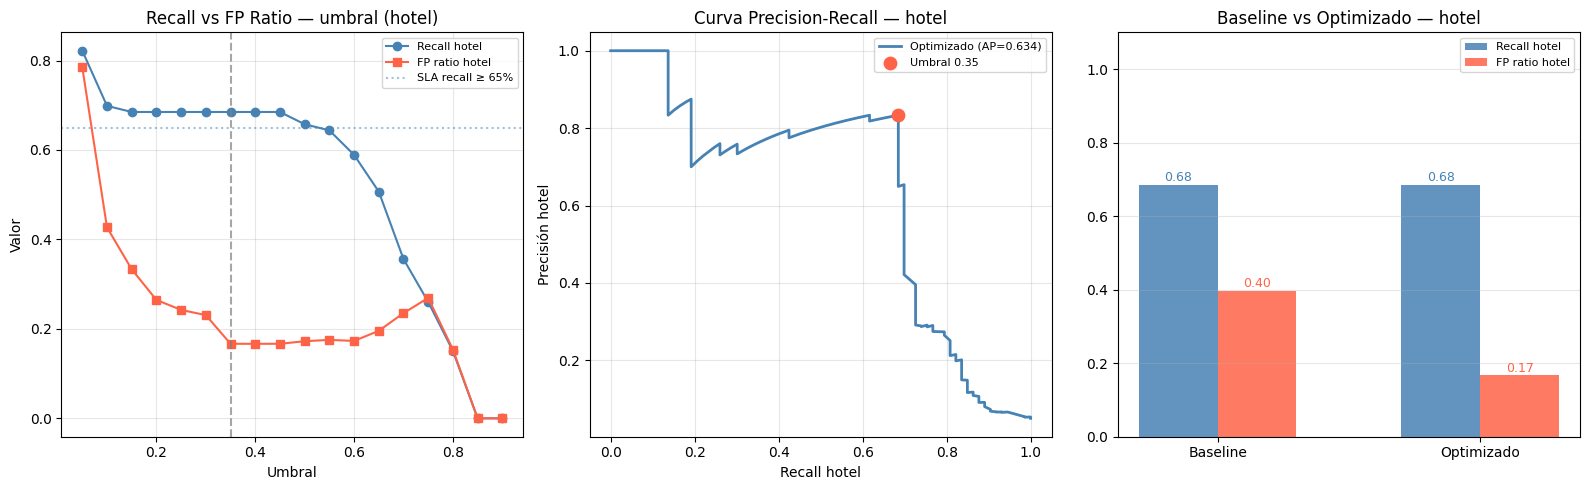

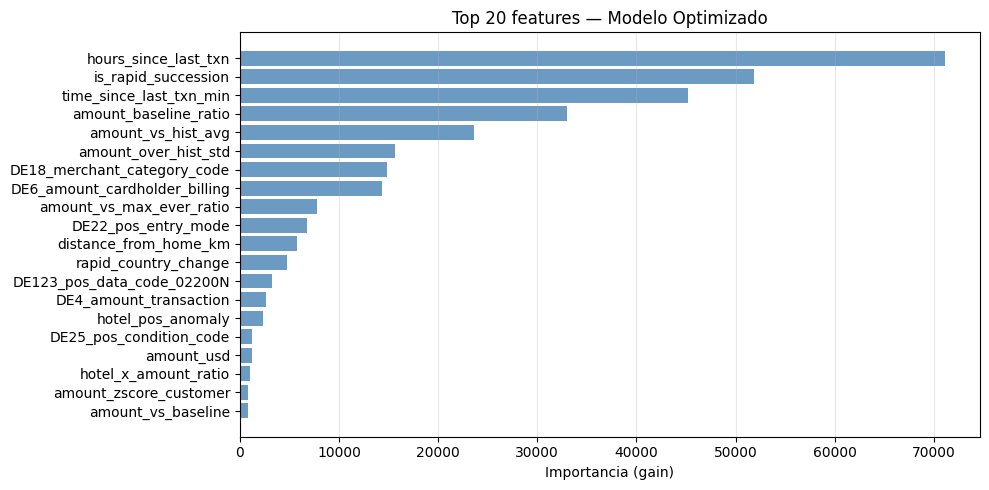

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Threshold sweep: Recall y FP ratio vs umbral ──
ax = axes[0]
ax.plot(thr_df["t"], thr_df["recall"],   "o-", color="steelblue", label="Recall hotel")
ax.plot(thr_df["t"], thr_df["fp_ratio"], "s-", color="tomato",    label="FP ratio hotel")
ax.axvline(best_t["t"], color="gray", linestyle="--", alpha=0.7)
ax.axhline(0.65, color="steelblue", linestyle=":", alpha=0.5, label="SLA recall ≥ 65%")
ax.set_xlabel("Umbral"); ax.set_ylabel("Valor")
ax.set_title("Recall vs FP Ratio — umbral (hotel)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Curva Precision-Recall (hotel) ──
ax2 = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_hotel, proba_hotel)
ap_hotel = average_precision_score(y_hotel, proba_hotel)
ax2.plot(rec_c, prec_c, color="steelblue", linewidth=2,
         label=f"Optimizado (AP={ap_hotel:.3f})")
ax2.scatter([best_t["recall"]], [best_t["precision"]],
            color="tomato", zorder=5, s=80, label=f"Umbral {best_t['t']:.2f}")
ax2.set_xlabel("Recall hotel"); ax2.set_ylabel("Precisión hotel")
ax2.set_title("Curva Precision-Recall — hotel"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Comparación baseline vs optimizado (barras) ──
ax3 = axes[2]
models   = ["Baseline", "Optimizado"]
recalls  = [BASELINE_HOTEL["recall_hotel"],   OPT_HOTEL["recall_hotel"]]
fp_ratios= [BASELINE_HOTEL["fp_ratio_hotel"], OPT_HOTEL["fp_ratio_hotel"]]
x        = np.arange(2); w = 0.3
ax3.bar(x - w/2, recalls,   w, label="Recall hotel",   color="steelblue", alpha=0.85)
ax3.bar(x + w/2, fp_ratios, w, label="FP ratio hotel", color="tomato",    alpha=0.85)
for i, (r, f) in enumerate(zip(recalls, fp_ratios)):
    ax3.text(i-w/2, r+0.01, f"{r:.2f}", ha="center", fontsize=9, color="steelblue")
    ax3.text(i+w/2, f+0.01, f"{f:.2f}", ha="center", fontsize=9, color="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(models)
ax3.set_ylim(0, 1.1); ax3.set_title("Baseline vs Optimizado — hotel")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Feature importance del modelo final ──
fi = pd.DataFrame({
    "feature":    final_model.feature_name(),
    "importance": final_model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue", alpha=0.8)
plt.xlabel("Importancia (gain)"); plt.title("Top 20 features — Modelo Optimizado")
plt.grid(alpha=0.3, axis="x"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Guardar resultados

In [12]:
with open(RESULTS_DIR / "best_params_optuna.json", "w") as f:
    json.dump({**best_params, "best_iteration": best_n_iter,
               "best_val_score_m2": best.value}, f, indent=2)

preds_out = pd.DataFrame({
    "transaction_id":       test_df["transaction_id"].values
                            if "transaction_id" in test_df.columns
                            else np.arange(len(test_df)),
    "is_hotel":             hotel_mask_test,
    "is_fraud_real":        y_test_np.astype(bool),
    "fraud_prob_optimized": proba_test.round(6),
    "pred_optimized":       (proba_test >= best_t["t"]).astype(bool),
    "threshold_used":       best_t["t"],
})
preds_out.to_csv(RESULTS_DIR / "optimized_predictions_june.csv", index=False)
comparison.to_csv(RESULTS_DIR / "comparison_baseline_vs_optimized.csv", index=False)

print("Archivos guardados en results/")
print()
print(comparison[["model","threshold","tp_hotel","fp_hotel",
                   "recall_pct","fp_ratio_pct","auc_roc"]].to_string(index=False))


Archivos guardados en results/

                                         model  threshold  tp_hotel  fp_hotel  recall_pct  fp_ratio_pct  auc_roc
    Baseline global nb03 (umbral óptimo hotel)       0.85        50        33        68.5          39.8 0.899500
Custom feval nb04 (hotel_recall_minus_fpratio)       0.01       182      2672        90.6          93.6 0.900400
Optimizado nb05 (Optuna, espacio regularizado)       0.35        50        10        68.5          16.7 0.899132
